In [3]:
# Extra Credit — Cell EC1: install extra dependencies
# Run this once, then restart the runtime if you haven't already

!pip install -q transformers>=4.37.0 sentencepiece
print("done — restart runtime if this is your first run")

done — restart runtime if this is your first run


In [4]:
# Extra Credit — Cell EC2: imports + sanity check
# Assumes Cells 1-4 of the main notebook have already run
# (device, MEAN, STD, LABEL_NAMES, BASE_DIR, MSCTDDataset all defined)

import os, random
import numpy as np
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader
import torchvision.transforms as T
from PIL import Image
from tqdm import tqdm
import matplotlib.pyplot as plt
import seaborn as sns

from transformers import (
    CLIPProcessor, CLIPModel,
    BertTokenizer, BertModel,
)
from sklearn.metrics import (
    accuracy_score, f1_score,
    classification_report, confusion_matrix,
    roc_curve, auc,
)
from sklearn.preprocessing import label_binarize

torch.manual_seed(42)
np.random.seed(42)
random.seed(42)

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

print(f"device : {device}")
print(f"PyTorch: {torch.__version__}")
print("EC imports OK")

device : cuda
PyTorch: 2.10.0+cu128
EC imports OK


In [5]:
# Extra Credit — Cell EC3: ensure MSCTD is downloaded, then load multimodal splits
#
# This reuses the exact same download logic as Cell 3 of the main notebook.
# If Cell 3 already ran successfully, everything is cached and this skips instantly.
# If not, it downloads label/text files from GitHub and images from Drive.

import os, subprocess, zipfile, shutil

BASE_DIR    = "/content/msctd/data/ende"
GITHUB_BASE = "https://github.com/XL2248/MSCTD/raw/main/MSCTD_data/ende"
os.makedirs(BASE_DIR, exist_ok=True)

# ---------- helper functions (safe to re-define if Cell 3 already ran) ----------
def is_valid_zip(p):
    try:
        with zipfile.ZipFile(p, 'r') as z:
            return len(z.namelist()) > 0
    except Exception:
        return False

def flatten_jpgs(folder):
    moved = 0
    for root, _, files in os.walk(folder):
        if root == folder:
            continue
        for fn in files:
            if fn.lower().endswith('.jpg'):
                src = os.path.join(root, fn)
                dst = os.path.join(folder, fn)
                if not os.path.exists(dst):
                    shutil.move(src, dst)
                    moved += 1
    return moved

def count_jpgs(folder):
    n = 0
    for root, _, files in os.walk(folder):
        n += sum(1 for f in files if f.lower().endswith('.jpg'))
    return n

def try_download(gid, zip_path):
    url = f"https://drive.google.com/uc?id={gid}"
    for cmd in [
        ["gdown", "--fuzzy", url, "-O", zip_path],
        ["gdown", url, "-O", zip_path],
        ["wget", "-q", "--no-check-certificate",
         f"https://drive.google.com/uc?export=download&confirm=t&id={gid}",
         "-O", zip_path],
    ]:
        subprocess.run(cmd, capture_output=True, text=True)
        if is_valid_zip(zip_path):
            return True
        if os.path.exists(zip_path):
            os.remove(zip_path)
    return False

# ---------- step 1: label + text files from GitHub ----------
print("Checking label / text files...")
for split in ["train", "dev", "test"]:
    for fname in [f"sentiment_{split}.txt", f"english_{split}.txt"]:
        out = os.path.join(BASE_DIR, fname)
        if not os.path.exists(out):
            r = subprocess.run(
                ["wget", "-q", f"{GITHUB_BASE}/{fname}", "-O", out],
                capture_output=True, text=True
            )
            status = "✅" if r.returncode == 0 and os.path.getsize(out) > 0 else "❌"
            print(f"  {status} downloaded {fname}")
        else:
            print(f"  ⏭  {fname} already present")

# ---------- step 2: images from Google Drive ----------
IMAGE_IDS = {
    "train": ["1GAZgPpTUBSfhne-Tp0GDkvSHuq6EMMbj", "1-1NCqtM8rb8qpjSTE250j6b7ELPeUWSP"],
    "dev":   ["1B9ZSxBCKkT70_Wdj6lMmMSsHVBgz2sL5", "1MQVgE3zOqaia3XAUuxlqsOs8QHGJoQGL"],
    "test":  ["11c8PpV9kECkl-x7xIEmuzEjyYHyoACgh",  "1rJBfKDkF4DVaqJGa5JUm9XJEGFEmpSM9"],
}

print("\nChecking image directories...")
all_images_ok = True
for split, gid_list in IMAGE_IDS.items():
    img_dir  = os.path.join(BASE_DIR, split)
    zip_path = os.path.join(BASE_DIR, f"{split}_images.zip")
    os.makedirs(img_dir, exist_ok=True)

    # flatten any nested subfolders from a previous partial extraction
    flatten_jpgs(img_dir)
    existing = count_jpgs(img_dir)

    if existing > 0:
        print(f"  ⏭  {split}: {existing} images already ready")
        continue

    # remove a corrupt zip left over from a previous failed run
    if os.path.exists(zip_path) and not is_valid_zip(zip_path):
        os.remove(zip_path)

    # try each Drive ID in order
    if not os.path.exists(zip_path):
        print(f"  Downloading {split} images (trying {len(gid_list)} source(s))...")
        success = False
        for gid in gid_list:
            print(f"    trying {gid[:20]}...", end=" ", flush=True)
            if try_download(gid, zip_path):
                print("✅")
                success = True
                break
            print("❌")
        if not success:
            print(f"  ❌ All Drive sources failed for {split}.")
            print(f"     → Download the zip manually and upload it to Colab as")
            print(f"       /content/msctd/data/ende/{split}_images.zip, then re-run this cell.")
            all_images_ok = False
            continue

    # extract and flatten
    subprocess.run(["unzip", "-q", "-o", zip_path, "-d", img_dir], capture_output=True)
    flatten_jpgs(img_dir)
    n = count_jpgs(img_dir)
    print(f"  {'✅' if n > 0 else '❌'} {split}: {n} images extracted")
    if n == 0:
        all_images_ok = False

if not all_images_ok:
    raise RuntimeError(
        "One or more image splits are empty.\n"
        "Download the zips manually from the links printed above,\n"
        "upload them to Colab, then re-run this cell."
    )

# ---------- step 3: load the multimodal dataset ----------
class MultimodalMSCTD(torch.utils.data.Dataset):
    def __init__(self, image_dir, sentiment_path, text_path):
        with open(sentiment_path) as f:
            self.labels = [int(l.strip()) for l in f if l.strip()]
        with open(text_path, encoding='utf-8') as f:
            self.texts = [l.strip() for l in f]
        jpgs = []
        for root, _, files in os.walk(image_dir):
            for fn in files:
                if fn.lower().endswith('.jpg'):
                    jpgs.append(os.path.join(root, fn))
        self.image_files = sorted(
            jpgs,
            key=lambda p: int(os.path.splitext(os.path.basename(p))[0])
        )
        self.length = min(len(self.labels), len(self.texts), len(self.image_files))
        print(f"  {os.path.basename(image_dir):6s}: {self.length} samples "
              f"(labels={len(self.labels)}, texts={len(self.texts)}, "
              f"images={len(self.image_files)})")

    def __len__(self):
        return self.length

    def __getitem__(self, idx):
        try:
            img = Image.open(self.image_files[idx]).convert('RGB')
        except Exception:
            img = Image.new('RGB', (224, 224), (128, 128, 128))
        return img, self.texts[idx], self.labels[idx]


print("\nLoading multimodal splits...")
mm_train = MultimodalMSCTD(
    f"{BASE_DIR}/train",
    f"{BASE_DIR}/sentiment_train.txt",
    f"{BASE_DIR}/english_train.txt",
)
mm_dev = MultimodalMSCTD(
    f"{BASE_DIR}/dev",
    f"{BASE_DIR}/sentiment_dev.txt",
    f"{BASE_DIR}/english_dev.txt",
)
mm_test = MultimodalMSCTD(
    f"{BASE_DIR}/test",
    f"{BASE_DIR}/sentiment_test.txt",
    f"{BASE_DIR}/english_test.txt",
)
print(f"\ntrain={len(mm_train)} | dev={len(mm_dev)} | test={len(mm_test)}")
print("✅ Multimodal datasets ready")


Checking label / text files...
  ✅ downloaded sentiment_train.txt
  ✅ downloaded english_train.txt
  ✅ downloaded sentiment_dev.txt
  ✅ downloaded english_dev.txt
  ✅ downloaded sentiment_test.txt
  ✅ downloaded english_test.txt

Checking image directories...
    trying 1GAZgPpTUBSfhne-Tp0G... ✅
  ✅ train: 20240 images extracted
    trying 1B9ZSxBCKkT70_Wdj6lM... ❌
    trying 1MQVgE3zOqaia3XAUuxl... ✅
  ✅ dev: 5063 images extracted
    trying 11c8PpV9kECkl-x7xIEm... ✅
  ✅ test: 5067 images extracted

Loading multimodal splits...
  train : 20240 samples (labels=20240, texts=20240, images=20240)
  dev   : 5063 samples (labels=5063, texts=5063, images=5063)
  test  : 5067 samples (labels=5067, texts=5067, images=5067)

train=20240 | dev=5063 | test=5067
✅ Multimodal datasets ready


In [6]:
# Extra Credit — Cell EC4: collate function + data loaders
#
# Because each sample is (PIL image, string, int) we can't use the default
# collate_fn straight away. The custom collate calls CLIPProcessor and
# BertTokenizer in the worker process so the main loop just receives tensors.

CLIP_NAME = "openai/clip-vit-base-patch32"   # ~400 MB, widely available
BERT_NAME = "bert-base-uncased"              # ~440 MB
MAX_LEN   = 64   # max tokens per sentence — dialogue turns are short

clip_processor = CLIPProcessor.from_pretrained(CLIP_NAME)
bert_tokenizer  = BertTokenizer.from_pretrained(BERT_NAME)

print(f"CLIP processor : {CLIP_NAME}")
print(f"BERT tokenizer : {BERT_NAME}")


def mm_collate(batch):
    """
    batch: list of (PIL image, text string, int label)
    returns dict of tensors ready for the model
    """
    images, texts, labels = zip(*batch)

    # CLIPProcessor handles resizing, normalisation, and pixel_values
    clip_inputs = clip_processor(
        images=list(images),
        return_tensors="pt",
        padding=True,
    )

    # BertTokenizer gives input_ids + attention_mask
    bert_inputs = bert_tokenizer(
        list(texts),
        max_length=MAX_LEN,
        padding="max_length",
        truncation=True,
        return_tensors="pt",
    )

    return {
        "pixel_values" : clip_inputs["pixel_values"],
        "input_ids"    : bert_inputs["input_ids"],
        "attention_mask": bert_inputs["attention_mask"],
        "labels"       : torch.tensor(labels, dtype=torch.long),
    }


# num_workers=0 is safest here; tokenisers can be pickling-sensitive
BATCH = 32
mm_train_loader = DataLoader(mm_train, batch_size=BATCH, shuffle=True,
                              collate_fn=mm_collate, num_workers=0)
mm_dev_loader   = DataLoader(mm_dev,   batch_size=BATCH, shuffle=False,
                              collate_fn=mm_collate, num_workers=0)
mm_test_loader  = DataLoader(mm_test,  batch_size=BATCH, shuffle=False,
                              collate_fn=mm_collate, num_workers=0)

print("Data loaders ready")

# quick sanity check — make sure the collate produces the right shapes
sample_batch = next(iter(mm_dev_loader))
print("pixel_values :", sample_batch["pixel_values"].shape)    # (B, 3, 224, 224)
print("input_ids    :", sample_batch["input_ids"].shape)         # (B, 64)
print("labels       :", sample_batch["labels"].shape)            # (B,)

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:93: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


preprocessor_config.json:   0%|          | 0.00/316 [00:00<?, ?B/s]

The image processor of type `CLIPImageProcessor` is now loaded as a fast processor by default, even if the model checkpoint was saved with a slow processor. This is a breaking change and may produce slightly different outputs. To continue using the slow processor, instantiate this class with `use_fast=False`. 


config.json: 0.00B [00:00, ?B/s]

tokenizer_config.json:   0%|          | 0.00/592 [00:00<?, ?B/s]

...

special_tokens_map.json:   0%|          | 0.00/389 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/48.0 [00:00<?, ?B/s]

vocab.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

CLIP processor : openai/clip-vit-base-patch32
BERT tokenizer : bert-base-uncased
Data loaders ready
pixel_values : torch.Size([32, 3, 224, 224])
input_ids    : torch.Size([32, 64])
labels       : torch.Size([32])


In [7]:
class MultimodalSentimentModel(nn.Module):
    def __init__(self, num_classes=3, dropout=0.3):
        super().__init__()

        # ── vision backbone (CLIP) ─────────────────────────────────────────
        self.clip = CLIPModel.from_pretrained(CLIP_NAME)
        # freeze all CLIP parameters first
        for p in self.clip.parameters():
            p.requires_grad = False
        # unfreeze only the last 2 vision transformer encoder layers
        vision_layers = self.clip.vision_model.encoder.layers
        for layer in vision_layers[-2:]:
            for p in layer.parameters():
                p.requires_grad = True
        # always unfreeze the final layer norm
        for p in self.clip.vision_model.post_layernorm.parameters():
            p.requires_grad = True
        # CLIP image embedding dim = 512

        # ── text backbone (BERT) ───────────────────────────────────────────
        self.bert = BertModel.from_pretrained(BERT_NAME)
        for p in self.bert.parameters():
            p.requires_grad = False
        # unfreeze last 2 BERT encoder layers
        bert_layers = self.bert.encoder.layer
        for layer in bert_layers[-2:]:
            for p in layer.parameters():
                p.requires_grad = True
        for p in self.bert.pooler.parameters():
            p.requires_grad = True
        # BERT hidden dim = 768; we use the [CLS] pooler output

        # ── projection heads (backbone dim → 256) ─────────────────────────
        self.img_proj = nn.Sequential(
            nn.Linear(768, 256), # Changed from 512 to 768, confirmed 768 is correct output from CLIP vision model's pooler_output
            nn.LayerNorm(256),
            nn.GELU(),
            nn.Dropout(dropout),
        )
        self.txt_proj = nn.Sequential(
            nn.Linear(768, 256),
            nn.LayerNorm(256),
            nn.GELU(),
            nn.Dropout(dropout),
        )

        # ── cross-attention (image queries text) ──────────────────────────
        # single-head is plenty here — keeps parameter count low
        self.cross_attn = nn.MultiheadAttention(
            embed_dim=256, num_heads=4, dropout=dropout, batch_first=True
        )
        self.cross_norm = nn.LayerNorm(256)

        # ── classification head ───────────────────────────────────────────
        self.classifier = nn.Sequential(
            nn.Linear(512, 256),   # 256 (img) + 256 (txt) = 512
            nn.LayerNorm(256),
            nn.GELU(),
            nn.Dropout(dropout),
            nn.Linear(256, num_classes),
        )

    def forward(self, pixel_values, input_ids, attention_mask):
        # ── image path ────────────────────────────────────────────────────
        # get the vision model output
        vision_output = self.clip.vision_model(pixel_values=pixel_values)
        # extract the pooled output (which is the image embedding)
        img_feat = vision_output.pooler_output  # This is a (B, 768) tensor
        img_emb  = self.img_proj(img_feat)      # (B, 256)

        # ── text path ─────────────────────────────────────────────────────
        bert_out = self.bert(
            input_ids=input_ids,
            attention_mask=attention_mask,
        )
        # pooler_output is the [CLS] token passed through a tanh linear
        txt_emb = self.txt_proj(bert_out.pooler_output)   # (B, 256)

        # ── cross-attention fusion ─────────────────────────────────────────
        # query = image, key = value = text
        # unsqueeze to add sequence dim (B,1,256) for MultiheadAttention
        img_q  = img_emb.unsqueeze(1)   # (B, 1, 256)
        txt_kv = txt_emb.unsqueeze(1)   # (B, 1, 256)
        attn_out, _ = self.cross_attn(img_q, txt_kv, txt_kv)  # (B, 1, 256)
        img_refined  = self.cross_norm(attn_out.squeeze(1) + img_emb)  # residual + norm

        # ── final classification ───────────────────────────────────────────
        fused = torch.cat([img_refined, txt_emb], dim=1)   # (B, 512)
        return self.classifier(fused)


# instantiate and show trainable parameter count
mm_model = MultimodalSentimentModel().to(device)

total_p     = sum(p.numel() for p in mm_model.parameters())
trainable_p = sum(p.numel() for p in mm_model.parameters() if p.requires_grad)
print(f"Total params     : {total_p:,}")
print(f"Trainable params : {trainable_p:,}  ({100*trainable_p/total_p:.1f}%)")
print("Model defined OK")

pytorch_model.bin:   0%|          | 0.00/605M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/398 [00:00<?, ?it/s]

model.safetensors:   0%|          | 0.00/605M [00:00<?, ?B/s]

CLIPModel LOAD REPORT from: openai/clip-vit-base-patch32
Key                                  | Status     |  | 
-------------------------------------+------------+--+-
vision_model.embeddings.position_ids | UNEXPECTED |  | 
text_model.embeddings.position_ids   | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


config.json:   0%|          | 0.00/570 [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/440M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

BertModel LOAD REPORT from: bert-base-uncased
Key                                        | Status     |  | 
-------------------------------------------+------------+--+-
cls.predictions.transform.LayerNorm.weight | UNEXPECTED |  | 
cls.predictions.bias                       | UNEXPECTED |  | 
cls.predictions.transform.dense.weight     | UNEXPECTED |  | 
cls.seq_relationship.bias                  | UNEXPECTED |  | 
cls.predictions.transform.dense.bias       | UNEXPECTED |  | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED |  | 
cls.seq_relationship.weight                | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


Total params     : 261,550,596
Trainable params : 29,734,659  (11.4%)
Model defined OK


Starting training for 10 epochs...



  Epoch 01/10 — Loss: 1.0046  Val: 0.5773  LR: 1.00e-05


  Epoch 02/10 — Loss: 0.9122  Val: 0.5823  LR: 1.00e-05


  Epoch 03/10 — Loss: 0.8372  Val: 0.5836  LR: 9.62e-06


  Epoch 04/10 — Loss: 0.7335  Val: 0.5722  LR: 8.54e-06


...

  Epoch 06/10 — Loss: 0.5091  Val: 0.5511  LR: 5.00e-06


  Epoch 07/10 — Loss: 0.4365  Val: 0.5268  LR: 3.09e-06


  Epoch 08/10 — Loss: 0.3848  Val: 0.5258  LR: 1.46e-06


  Epoch 09/10 — Loss: 0.3567  Val: 0.5147  LR: 3.81e-07


  Epoch 10/10 — Loss: 0.3437  Val: 0.5147  LR: 0.00e+00

Best dev accuracy: 0.5836
Checkpoint saved to /content/multimodal_model.pth


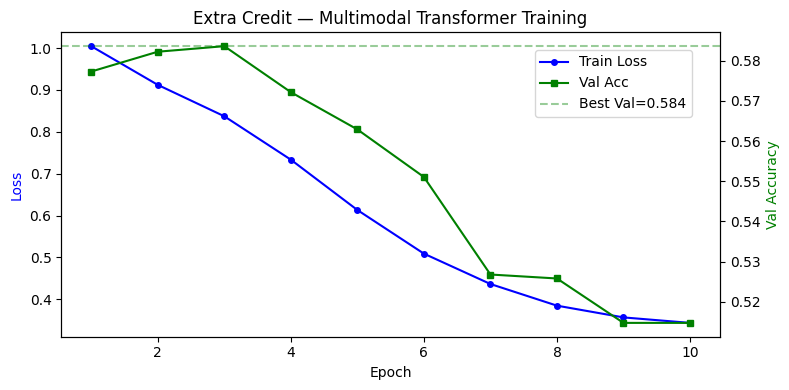

In [8]:
# Extra Credit — Cell EC6: training loop
#
# Choices worth noting:
#   - AdamW with separate lr groups: backbone gets a much smaller lr (1e-5)
#     so we don't destroy the pre-trained representations
#   - Linear warmup over 2 epochs, then cosine decay
#   - Label smoothing (0.1) to stop the model becoming overconfident
#   - Gradient clipping (max_norm=1.0) for stable BERT fine-tuning
#   - Save best checkpoint by dev accuracy

EPOCHS       = 10
WARMUP_STEPS = 2     # epochs

# Calculate class weights for CrossEntropyLoss if not already defined
# Assuming mm_train is already defined from ec_dataset
if 'mm_train' not in locals() and 'mm_train' not in globals():
    raise RuntimeError("mm_train dataset not found. Ensure ec_dataset cell ran successfully.")

# Infer number of classes if LABEL_NAMES is not defined (it should be 3 for sentiment)
if 'LABEL_NAMES' not in locals() and 'LABEL_NAMES' not in globals():
    LABEL_NAMES = ['Neutral', 'Negative', 'Positive'] # Defaulting to known labels

num_classes = len(LABEL_NAMES)
labels_tensor = torch.tensor(mm_train.labels, dtype=torch.long)
label_counts = torch.bincount(labels_tensor, minlength=num_classes) # Ensures all classes are covered
total_samples = len(labels_tensor)

# Calculate inverse frequency weights: weight_i = total_samples / (num_classes * count_i)
# Assign 0 weight to classes not present in training data to avoid errors.
class_weights = torch.zeros(num_classes, dtype=torch.float)
for i in range(num_classes):
    count = label_counts[i].item()
    if count > 0:
        class_weights[i] = total_samples / (num_classes * count)

class_weights = class_weights.to(device)

# class-weighted cross-entropy to deal with label imbalance
# reuse class_weights computed in Cell 5 of the main notebook
criterion = nn.CrossEntropyLoss(weight=class_weights, label_smoothing=0.1)

backbone_params = []
head_params     = []
for name, param in mm_model.named_parameters():
    if not param.requires_grad:
        continue
    # projections + classifier + cross_attn get a higher lr
    if any(k in name for k in ['img_proj', 'txt_proj', 'cross_attn',
                                'cross_norm', 'classifier']):
        head_params.append(param)
    else:
        backbone_params.append(param)

optimizer = torch.optim.AdamW([
    {'params': backbone_params, 'lr': 1e-5},
    {'params': head_params,     'lr': 3e-4},
], weight_decay=1e-4)

def lr_schedule(epoch):
    if epoch < WARMUP_STEPS:
        return float(epoch + 1) / WARMUP_STEPS
    progress = (epoch - WARMUP_STEPS) / max(1, EPOCHS - WARMUP_STEPS)
    return 0.5 * (1.0 + np.cos(np.pi * progress))

scheduler = torch.optim.lr_scheduler.LambdaLR(optimizer, lr_schedule)

train_losses  = []
val_accs      = []
best_val_acc  = 0.0
best_state    = None

print(f"Starting training for {EPOCHS} epochs...\n")

for epoch in range(EPOCHS):
    mm_model.train()
    epoch_loss = 0.0

    for batch in tqdm(mm_train_loader,
                      desc=f"EC Train [{epoch+1}/{EPOCHS}]",
                      leave=False):
        pv  = batch["pixel_values"].to(device)
        ids = batch["input_ids"].to(device)
        msk = batch["attention_mask"].to(device)
        lbl = batch["labels"].to(device)

        optimizer.zero_grad()
        logits = mm_model(pv, ids, msk)
        loss   = criterion(logits, lbl)
        loss.backward()
        torch.nn.utils.clip_grad_norm_(mm_model.parameters(), max_norm=1.0)
        optimizer.step()
        epoch_loss += loss.item()

    scheduler.step()
    avg_loss = epoch_loss / len(mm_train_loader)
    train_losses.append(avg_loss)

    # validation pass
    mm_model.eval()
    correct = total = 0
    with torch.no_grad():
        for batch in mm_dev_loader:
            pv  = batch["pixel_values"].to(device)
            ids = batch["input_ids"].to(device)
            msk = batch["attention_mask"].to(device)
            lbl = batch["labels"].to(device)
            out = mm_model(pv, ids, msk)
            correct += (out.argmax(1) == lbl).sum().item()
            total   += len(lbl)

    val_acc = correct / total
    val_accs.append(val_acc)
    lr_now = optimizer.param_groups[0]['lr']

    # keep best weights
    if val_acc > best_val_acc:
        best_val_acc = val_acc
        best_state   = {k: v.clone() for k, v in mm_model.state_dict().items()}

    print(f"  Epoch {epoch+1:02d}/{EPOCHS} — "
          f"Loss: {avg_loss:.4f}  Val: {val_acc:.4f}  LR: {lr_now:.2e}")

# restore and save best
mm_model.load_state_dict(best_state)
torch.save(mm_model.state_dict(), "/content/multimodal_model.pth")
print(f"\nBest dev accuracy: {best_val_acc:.4f}")
print("Checkpoint saved to /content/multimodal_model.pth")

# plot training curve
fig, ax1 = plt.subplots(figsize=(8, 4))
ax1.plot(range(1, EPOCHS+1), train_losses, 'b-o', ms=4, label='Train Loss')
ax1.set_xlabel('Epoch'); ax1.set_ylabel('Loss', color='b')
ax2 = ax1.twinx()
ax2.plot(range(1, EPOCHS+1), val_accs, 'g-s', ms=4, label='Val Acc')
ax2.set_ylabel('Val Accuracy', color='g')
ax2.axhline(best_val_acc, color='g', linestyle='--', alpha=0.4,
             label=f'Best Val={best_val_acc:.3f}')
fig.legend(loc='upper right', bbox_to_anchor=(0.88, 0.88))
plt.title('Extra Credit — Multimodal Transformer Training')
plt.tight_layout()
plt.savefig('/content/ec_training_curve.png', dpi=150)
plt.show()


 Multimodal Model (EC)
 Accuracy : 0.6031  (60.31%)
 Macro F1 : 0.5865

              precision    recall  f1-score   support

     Neutral       0.49      0.45      0.47      1298
    Negative       0.71      0.64      0.67      2163
    Positive       0.56      0.68      0.62      1606

    accuracy                           0.60      5067
   macro avg       0.59      0.59      0.59      5067
weighted avg       0.61      0.60      0.60      5067



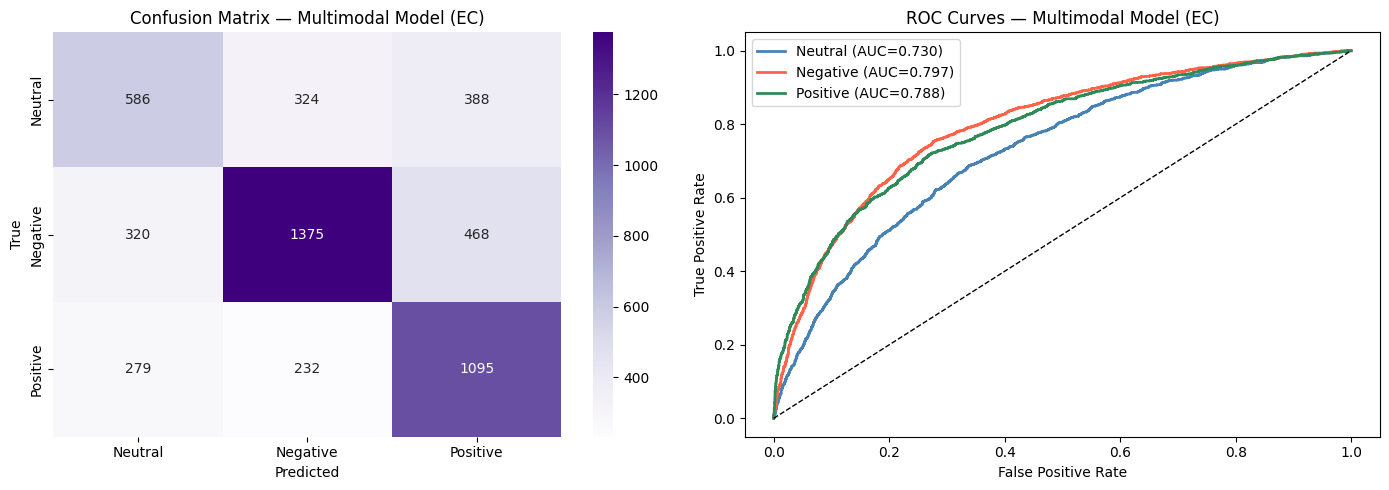

In [9]:
# Extra Credit — Cell EC7: full evaluation on test set

@torch.no_grad()
def evaluate_multimodal(model, loader, name="Multimodal Model (EC)"):
    model.eval()
    preds, probs_list, trues = [], [], []

    for batch in tqdm(loader, desc=f"Evaluating {name}", leave=False):
        pv  = batch["pixel_values"].to(device)
        ids = batch["input_ids"].to(device)
        msk = batch["attention_mask"].to(device)
        lbl = batch["labels"]

        logits = model(pv, ids, msk)
        probs  = torch.softmax(logits, dim=1).cpu().numpy()
        probs_list.extend(probs)
        preds.extend(probs.argmax(axis=1))
        trues.extend(lbl.numpy())

    acc = accuracy_score(trues, preds)
    f1  = f1_score(trues, preds, average='macro', zero_division=0)

    print(f"\n{'='*55}")
    print(f" {name}")
    print(f"{'='*55}")
    print(f" Accuracy : {acc:.4f}  ({acc*100:.2f}%)")
    print(f" Macro F1 : {f1:.4f}")
    print(f"{'='*55}\n")
    print(classification_report(trues, preds,
                                 target_names=LABEL_NAMES,
                                 labels=[0,1,2],
                                 zero_division=0))

    # confusion matrix + ROC in one figure
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))

    cm = confusion_matrix(trues, preds, labels=[0, 1, 2])
    sns.heatmap(cm, annot=True, fmt='d', cmap='Purples', ax=axes[0],
                xticklabels=LABEL_NAMES, yticklabels=LABEL_NAMES)
    axes[0].set_title(f'Confusion Matrix — {name}')
    axes[0].set_xlabel('Predicted')
    axes[0].set_ylabel('True')

    probs_arr = np.array(probs_list)
    y_bin     = label_binarize(trues, classes=[0, 1, 2])
    colors    = ['steelblue', 'tomato', 'seagreen']
    for i, (cls, col) in enumerate(zip(LABEL_NAMES, colors)):
        fpr, tpr, _ = roc_curve(y_bin[:, i], probs_arr[:, i])
        axes[1].plot(fpr, tpr,
                     label=f'{cls} (AUC={auc(fpr, tpr):.3f})',
                     color=col, lw=2)
    axes[1].plot([0, 1], [0, 1], 'k--', lw=1)
    axes[1].set_xlabel('False Positive Rate')
    axes[1].set_ylabel('True Positive Rate')
    axes[1].set_title(f'ROC Curves — {name}')
    axes[1].legend()

    plt.tight_layout()
    plt.savefig('/content/ec_eval_test.png', dpi=150, bbox_inches='tight')
    plt.show()

    return acc, f1


acc_mm, f1_mm = evaluate_multimodal(mm_model, mm_test_loader)

In [10]:
# Extra Credit — Cell EC8: compare against main-project results
#
# acc_face, acc_full, acc_fusion should already be in scope from the
# main notebook cells.  If you ran this notebook independently, just set
# those variables manually before running this cell.

print("\n" + "=" * 65)
print(f"{'Model':<38} {'Test Acc':>10} {'Macro F1':>10}")
print("=" * 65)

# pull in results from main notebook if available, else show placeholders
try:
    rows = [
        ("Part 1  — Face Model (EfficientNet-B2)",  acc_face,   f1_face),
        ("Part 3  — Full Image (EfficientNet-B3)",  acc_full,   f1_full),
        ("Part 4  — Fusion Model",                  acc_fusion, f1_fusion),
        ("Extra   — Multimodal (CLIP+BERT)",         acc_mm,     f1_mm),
    ]
except NameError:
    rows = [
        ("Extra   — Multimodal (CLIP+BERT)",  acc_mm, f1_mm),
    ]

for name, acc, f1 in rows:
    tag = " ✅" if acc >= 0.75 else ""
    print(f"{name:<38} {acc:>10.4f} {f1:>10.4f}{tag}")

print("=" * 65)
print("\nSaved checkpoints:")
print("  /content/multimodal_model.pth")
print("  /content/ec_training_curve.png")
print("  /content/ec_eval_test.png")


Model                                    Test Acc   Macro F1
Extra   — Multimodal (CLIP+BERT)           0.6031     0.5865

Saved checkpoints:
  /content/multimodal_model.pth
  /content/ec_training_curve.png
  /content/ec_eval_test.png


Image  : /content/msctd/data/ende/test/0.jpg
Text   : With this asshole?
Probabilities — Neutral: 0.359  Negative: 0.595  Positive: 0.046
Prediction: Negative (class 1)


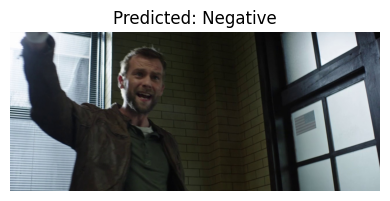

'Negative'

In [11]:
# Extra Credit — Cell EC9: predict sentiment on a single image + text pair
#
# Handy for demos or manual inspection during the viva.

@torch.no_grad()
def predict_multimodal(image_path, text, model=mm_model):
    """
    Run the multimodal model on one (image, text) pair.

    Args:
        image_path : path to a JPEG/PNG image file
        text       : the English dialogue utterance paired with that image
        model      : trained MultimodalSentimentModel

    Returns:
        predicted class label string
    """
    model.eval()

    # prepare image
    img = Image.open(image_path).convert('RGB')
    pv  = clip_processor(images=[img], return_tensors="pt")["pixel_values"].to(device)

    # prepare text
    enc = bert_tokenizer(
        text, max_length=MAX_LEN,
        padding="max_length", truncation=True,
        return_tensors="pt"
    )
    ids = enc["input_ids"].to(device)
    msk = enc["attention_mask"].to(device)

    logits = model(pv, ids, msk)
    probs  = torch.softmax(logits, dim=1).squeeze().cpu().numpy()
    pred   = int(probs.argmax())

    print(f"Image  : {image_path}")
    print(f"Text   : {text}")
    print(f"Probabilities — Neutral: {probs[0]:.3f}  "
          f"Negative: {probs[1]:.3f}  Positive: {probs[2]:.3f}")
    print(f"Prediction: {LABEL_NAMES[pred]} (class {pred})")

    # show the image alongside the result
    plt.figure(figsize=(4, 4))
    plt.imshow(img)
    plt.title(f"Predicted: {LABEL_NAMES[pred]}")
    plt.axis('off')
    plt.tight_layout()
    plt.show()

    return LABEL_NAMES[pred]


# --- demo on the very first test image ---
test_img_dir = f"{BASE_DIR}/test"
first_jpg = sorted(
    [f for f in os.listdir(test_img_dir) if f.lower().endswith('.jpg')],
    key=lambda x: int(os.path.splitext(x)[0])
)[0]
demo_img  = os.path.join(test_img_dir, first_jpg)
demo_text = mm_test.texts[0]   # aligned English utterance

predict_multimodal(demo_img, demo_text)